# Notebook de documentacion, tratamiento datos y entrenamiento

## Equipo
- Alumno 1: Juana Chies Doumecq
- Alumno 2: Nicolas Mancini

# 1. Librerías y configuración de dispositivo

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import TensorDataset, DataLoader, random_split

from facenet_pytorch import InceptionResnetV1

from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import Counter
import warnings
import timm
import albumentations as A
import os
import random

import insightface
from insightface.app import FaceAnalysis
from insightface.utils import face_align

import cv2

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Dispositivo: {device}')

# SEED
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


PyTorch: 2.2.2+cu121 | Dispositivo: cuda


# 2. Dataset

## 2.1 Descarga del dataset público (LFW)

In [4]:
lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)
X_lfw = lfw.images
y_lfw = lfw.target
NOMBRES = lfw.target_names
NUM_CLASES = len(NOMBRES)

print(f'Dataset: {X_lfw.shape[0]} imágenes, {len(NOMBRES)} personas')
print(f'Resolución: {X_lfw.shape[1]}x{X_lfw.shape[2]} px')

conteo = Counter(y_lfw)
print(f'Imágenes por persona — min: {min(conteo.values())}, max: {max(conteo.values())}, mediana: {int(np.median(list(conteo.values())))}')

Dataset: 4324 imágenes, 158 personas
Resolución: 125x94 px
Imágenes por persona — min: 10, max: 530, mediana: 17


## 2.2 Descarga del dataset propio

In [5]:
DATA_DIR = "src/data"

# Cargar dataset propio si existe
if os.path.isdir(DATA_DIR):
    personas = sorted([
        d for d in os.listdir(DATA_DIR)
        if os.path.isdir(os.path.join(DATA_DIR, d))
    ])
else:
    personas = []

if personas:
    X_own, y_own_local = [], []
    for clase_id, persona in enumerate(personas):
        carpeta = os.path.join(DATA_DIR, persona)
        for archivo in sorted(os.listdir(carpeta)):
            if not archivo.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                continue
            ruta = os.path.join(carpeta, archivo)
            try:
                img = Image.open(ruta).convert('RGB').resize((94, 125))
                X_own.append(np.array(img, dtype=np.float32) / 255.0)
                y_own_local.append(clase_id)
            except Exception as e:
                print(f'  [WARN] {ruta}: {e}')
        print(f'  {persona}: {len([f for f in os.listdir(carpeta) if f.lower().endswith((".jpg",".jpeg",".png",".webp"))])} imágenes')

    X_own      = np.array(X_own)
    y_own      = np.array(y_own_local) + NUM_CLASES  # offset para no colisionar con LFW

    X_combined = np.concatenate([X_lfw, X_own])
    y_combined = np.concatenate([y_lfw, y_own])
    NOMBRES    = np.array(list(NOMBRES) + personas)
    NUM_CLASES = len(NOMBRES)

    print(f'\nLFW:    {len(X_lfw)} imgs, {NUM_CLASES - len(personas)} personas')
    print(f'Propio: {len(X_own)} imgs, {len(personas)} personas')
    print(f'Total:  {len(X_combined)} imgs, {NUM_CLASES} personas')

else:
    print('Sin dataset propio — usando solo LFW')
    X_combined = X_lfw
    y_combined = y_lfw

Sin dataset propio — usando solo LFW


# 3. Funciones

In [6]:
def lfw_to_pil(img_np):
    """Convierte imagen LFW (H, W, 3) float32 [0,1] a PIL RGB."""
    return Image.fromarray((img_np * 255).astype(np.uint8), mode='RGB')

In [7]:
def imgs_to_tensor(X, transform):
    """
    Convierte un conjunto de imágenes en tensores de PyTorch aplicando una transformación
    a cada imagen y apilándolas en un único tensor.
    """
    tensors = []
    for img in X:
        pil = lfw_to_pil(img)
        tensors.append(transform(pil))
    return torch.stack(tensors)

In [8]:
def analizar_errores(y_true, y_pred, nombres, modelo_nombre, top_k=10):
    """
    Analiza los errores de clasificación del modelo, mostrando las clases con más falsos negativos
    y las confusiones más frecuentes entre clases reales y predichas.
    """
    errores = [(y_true[i], y_pred[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]

    fn_por_clase = Counter(real for real, _ in errores)
    print(f'\n{modelo_nombre} — Clases con más falsos negativos (peor recall):')
    for clase_id, count in fn_por_clase.most_common(top_k):
        total = (y_true == clase_id).sum()
        print(f'  {nombres[clase_id]:<30} {count}/{total} errores ({count/total:.0%})')

    pares = Counter(errores)
    print(f'\n{modelo_nombre} — Confusiones más frecuentes:')
    for (real, pred), count in pares.most_common(top_k):
        print(f'  {nombres[real]:<25} → {nombres[pred]:<25} ({count}x)')

In [9]:
def graficar_tsne(embeddings, labels, nombres, titulo='t-SNE de embeddings faciales', perplexity=15):
    """
    Visualiza embeddings en 2D usando t-SNE.

    Args:
        embeddings : np.ndarray (N, D) — embeddings del modelo
        labels     : np.ndarray (N,)   — etiquetas numéricas
        nombres    : list[str]         — lista de nombres (índice = label)
        titulo     : str               — título del gráfico
        perplexity : int               — perplexity del t-SNE
    """
    tsne  = TSNE(n_components=2, random_state=42, perplexity=min(perplexity, len(embeddings) - 1))
    emb_2d = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(14, 14))
    colores = plt.cm.tab10(np.linspace(0, 1, len(nombres)))

    for persona_id, nombre in enumerate(nombres):
        mask = labels == persona_id
        if mask.any():
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])

    ax.legend(fontsize=7, loc='best', ncol=3)
    ax.set_title(titulo)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [10]:
def graficar_entrenamiento(history, nombre='Modelo'):
    """
    Visualiza las curvas de entrenamiento (loss y accuracy).

    Args:
        history : dict con claves 'train_loss', 'val_loss', 'train_acc', 'val_acc'
        nombre  : str — nombre del modelo para el título
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Entrenamiento — {nombre}', fontsize=13, fontweight='bold')

    # Loss
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato', linestyle='--')
    ax1.set_title('Loss por época'); ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='tomato', linestyle='--')
    ax2.set_title('Accuracy por época'); ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [11]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=1.0),
    ], p=0.7),
    A.Rotate(limit=15, p=0.4),
    A.CoarseDropout(max_holes=1, max_height=20, max_width=20, p=0.3),
])


def balancear_exacto(X, y, target_count=None):
    """
    Deja exactamente target_count imágenes por clase.
    Aplica undersampling a clases con exceso y oversampling con
    augmentation a clases con déficit.
    """
    conteo = Counter(y)
    if target_count is None:
        target_count = int(np.median(list(conteo.values())))
        print(f'Target automático (mediana): {target_count} imágenes por clase')

    X_final, y_final = [], []

    for clase, cantidad in sorted(conteo.items()):
        idx        = np.where(y == clase)[0]
        imgs_clase = X[idx]
        nombre     = NOMBRES[clase]

        if cantidad >= target_count:
            elegidos = np.random.choice(len(imgs_clase), target_count, replace=False)
            X_final.append(imgs_clase[elegidos])
            print(f'  {nombre}: {cantidad} → {target_count}')
        else:
            X_clase   = list(imgs_clase)
            necesarias = target_count - cantidad
            generadas  = 0
            while generadas < necesarias:
                img       = imgs_clase[np.random.randint(len(imgs_clase))]
                img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
                img_aug   = transform(image=img_uint8)['image'].astype(np.float32) / 255.0
                X_clase.append(img_aug)
                generadas += 1
            X_final.append(np.array(X_clase))
            print(f'  {nombre}: {cantidad} → {target_count} (+{necesarias} generadas)')

        y_final.append(np.full(target_count, clase))

    X_final    = np.concatenate(X_final, axis=0)
    y_final    = np.concatenate(y_final, axis=0)
    idx_shuffle = np.random.permutation(len(y_final))

    # ejemplos visuales para verificar augmentation
    ejemplos_aug = {}
    for clase, cantidad in sorted(conteo.items()):
        if cantidad < target_count:
            idx       = np.where(y == clase)[0]
            img_base  = X[idx[0]]
            img_uint8 = (np.clip(img_base, 0, 1) * 255).astype(np.uint8)
            aumentadas = []
            for _ in range(3):
                aug = transform(image=img_uint8)['image']
                aumentadas.append(aug)
            ejemplos_aug[clase] = {'original': img_uint8, 'aumentadas': aumentadas}

    return X_final[idx_shuffle], y_final[idx_shuffle], ejemplos_aug

In [12]:
def mtcnn_to_imagenet(t):
    """Convierte tensor MTCNN [-1,1] → normalización ImageNet."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=t.device).view(3,1,1)
    return (t - mean) / std

In [13]:
def correr_insightface(X, y, detector, face_size, desc=''):
    faces, labels = [], []

    for i, (img, label) in enumerate(zip(X, y)):
        img_bgr = (np.clip(img, 0, 1) * 255).astype(np.uint8)[:, :, ::-1]
        dets    = detector.get(img_bgr)
        if not dets:
            continue

        det  = max(dets, key=lambda d: d.det_score)
        bbox = det.bbox.astype(int)
        x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

        # margen del 20% del tamaño del bounding box
        h, w   = img_bgr.shape[:2]
        margin = int(max(x2 - x1, y2 - y1) * 0.2)
        x1 = max(0, x1 - margin)
        y1 = max(0, y1 - margin)
        x2 = min(w, x2 + margin)
        y2 = min(h, y2 + margin)

        crop        = img_bgr[y1:y2, x1:x2]
        aligned     = cv2.resize(crop, (face_size, face_size),
                                 interpolation=cv2.INTER_LINEAR)
        aligned_rgb = aligned[:, :, ::-1].astype(np.float32) / 255.0
        tensor      = torch.tensor(aligned_rgb).permute(2, 0, 1)
        tensor      = (tensor - 0.5) / 0.5

        faces.append(tensor)
        labels.append(label)

        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(X)} procesadas...', end='\r')

    print(f'  [{desc}] {len(faces)}/{len(X)} con cara detectada')
    return torch.stack(faces), np.array(labels)

In [14]:
def visualizar_augmentation(ejemplos_aug, detector, NOMBRES, face_size=160, n_clases=3):
    """
    Muestra el pipeline completo de augmentation + InsightFace para n_clases aleatorias.
    Columnas: Original | Aug1 | IF1 | Aug2 | IF2 | Aug3 | IF3
    """
    clases_viz = np.random.choice(list(ejemplos_aug.keys()), size=n_clases, replace=False)
    titulos    = ['Original', 'Aug 1', 'IF 1', 'Aug 2', 'IF 2', 'Aug 3', 'IF 3']

    fig, axes = plt.subplots(n_clases, 7, figsize=(18, n_clases * 3.5))
    fig.suptitle(f'Augmentation + InsightFace ({face_size}px)', fontsize=13, fontweight='bold')

    for col, titulo in enumerate(titulos):
        axes[0, col].set_title(titulo, fontsize=9)

    for row, clase in enumerate(clases_viz):
        data      = ejemplos_aug[clase]
        nombre    = NOMBRES[clase].split()[-1]
        imgs_show = [data['original']]

        for aug in data['aumentadas']:
            imgs_show.append(aug)
            # InsightFace espera BGR uint8
            img_bgr = aug[:, :, ::-1].copy()
            dets    = detector.get(img_bgr)
            if dets:
                det      = max(dets, key=lambda d: d.det_score)
                aligned  = face_align.norm_crop(img_bgr, landmark=det.kps, image_size=face_size)
                imgs_show.append(aligned[:, :, ::-1])  # BGR → RGB para imshow
            else:
                imgs_show.append(None)

        for col, img in enumerate(imgs_show):
            ax = axes[row, col]
            if img is None:
                ax.text(0.5, 0.5, 'No\ndetectada', ha='center', va='center',
                        fontsize=8, color='red', transform=ax.transAxes)
            else:
                ax.imshow(img)
            ax.axis('off')

        axes[row, 0].set_ylabel(nombre, fontsize=10, rotation=0, labelpad=50, va='center')

    plt.tight_layout()
    plt.show()

# 4. Preprocesamiento

## 4.1 Split: Train / Val / Test




El split se hace antes de extraer embeddings, sobre el dataset balanceado (`X_bal`/`y_bal`).  
Dividimos en 3 partes: train (67%), validación (13%) y test (20%), con las mismas proporciones  
para todos los modelos. Esto garantiza una comparación justa:  
- **Train**: para finetuning de pesos.  
- **Val**: para early stopping y selección del mejor checkpoint durante el finetuning.  
- **Test**: evaluación final, solo se usa al final, nunca durante el entrenamiento.

In [16]:
X_temp, X_test, y_temp, y_test = train_test_split(X_combined, y_combined, test_size=0.20, stratify=y_combined, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.165, stratify=y_temp, random_state=SEED)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Clases: {NUM_CLASES}')

Train: 2888 | Val: 571 | Test: 865
Clases: 158


## 4.2 Balanceo


In [17]:
X_train_balanceado, y_train_balanceado, ejemplos_aug = balancear_exacto(X_train, y_train, target_count=20)

  Abdullah Gul: 13 → 20 (+7 generadas)
  Adrien Brody: 8 → 20 (+12 generadas)
  Alejandro Toledo: 26 → 20
  Alvaro Uribe: 23 → 20
  Amelie Mauresmo: 14 → 20 (+6 generadas)
  Andre Agassi: 24 → 20
  Andy Roddick: 10 → 20 (+10 generadas)
  Angelina Jolie: 13 → 20 (+7 generadas)
  Ann Veneman: 7 → 20 (+13 generadas)
  Anna Kournikova: 8 → 20 (+12 generadas)
  Ari Fleischer: 8 → 20 (+12 generadas)
  Ariel Sharon: 51 → 20
  Arnold Schwarzenegger: 28 → 20
  Atal Bihari Vajpayee: 16 → 20 (+4 generadas)
  Bill Clinton: 19 → 20 (+1 generadas)
  Bill Gates: 12 → 20 (+8 generadas)
  Bill McBride: 7 → 20 (+13 generadas)
  Bill Simon: 10 → 20 (+10 generadas)
  Britney Spears: 9 → 20 (+11 generadas)
  Carlos Menem: 14 → 20 (+6 generadas)
  Carlos Moya: 13 → 20 (+7 generadas)
  Catherine Zeta-Jones: 7 → 20 (+13 generadas)
  Charles Moose: 8 → 20 (+12 generadas)
  Colin Powell: 158 → 20
  Condoleezza Rice: 7 → 20 (+13 generadas)
  David Beckham: 21 → 20
  David Nalbandian: 9 → 20 (+11 generadas)
  Dic

## 4.3 Modelo para detección de caras



In [18]:
detector_if = FaceAnalysis(name='buffalo_sc', allowed_modules=['detection'])
detector_if.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(320, 320))
print(f'InsightFace inicializado en {"GPU" if torch.cuda.is_available() else "CPU"}')

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition
set det-size: (320, 320)
InsightFace inicializado en GPU


In [19]:
print('Corriendo InsightFace 112px (FaceNet)...')
train_faces_112, train_lbl_112 = correr_insightface(X_train_balanceado, y_train_balanceado, detector_if, 112, 'train')
val_faces_112,   val_lbl_112   = correr_insightface(X_val,   y_val,       detector_if, 112, 'val')
test_faces_112,  test_lbl_112  = correr_insightface(X_test,  y_test,      detector_if, 112, 'test')

print('\nCorriendo InsightFace 224px (ViT / ResNet-50)...')
train_faces_224, train_lbl_224 = correr_insightface(X_train_balanceado, y_train_balanceado, detector_if, 224, 'train')
val_faces_224,   val_lbl_224   = correr_insightface(X_val,   y_val,       detector_if, 224, 'val')
test_faces_224,  test_lbl_224  = correr_insightface(X_test,  y_test,      detector_if, 224, 'test')

Corriendo InsightFace 112px (FaceNet)...
  [train] 3160/3160 con cara detectada
  [val] 571/571 con cara detectada
  [test] 865/865 con cara detectada

Corriendo InsightFace 224px (ViT / ResNet-50)...
  [train] 3160/3160 con cara detectada
  [val] 571/571 con cara detectada
  [test] 865/865 con cara detectada


## 4.5 Visualización (Data Augmentation)

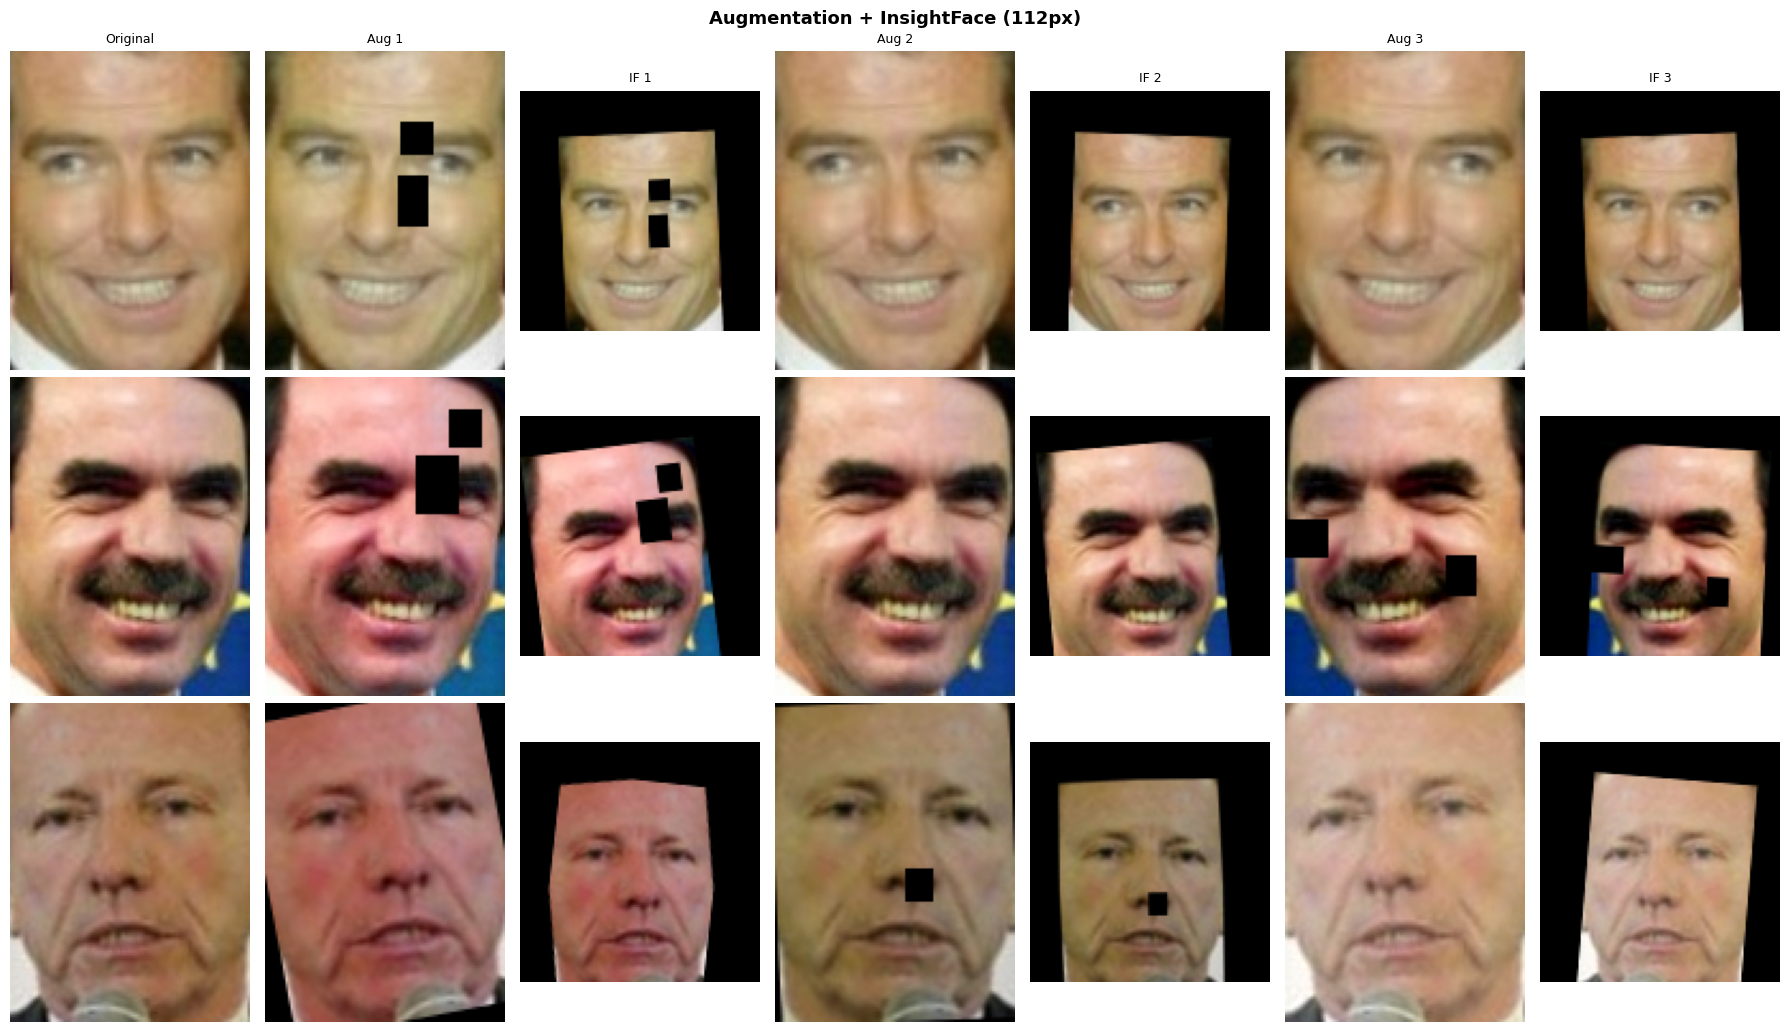

In [20]:
visualizar_augmentation(ejemplos_aug, detector_if, NOMBRES, face_size=112)

Los resultados muestran que el proceso de data augmentation genera variaciones realistas de las imágenes originales (rotaciones, cambios de iluminación y ruido), mientras que - continúa detectando y alineando correctamente los rostros, demostrando la robustez y efectividad del preprocesamiento aplicado.

## 4.6 Pre-normalizar a ImageNet (ViT y ResNet-50)

In [21]:
train_faces_224 = torch.stack([mtcnn_to_imagenet(t) for t in train_faces_224])
val_faces_224   = torch.stack([mtcnn_to_imagenet(t) for t in val_faces_224])
test_faces_224  = torch.stack([mtcnn_to_imagenet(t) for t in test_faces_224])

print(f'train_faces_224_in: {train_faces_224.shape}')
print(f'val_faces_224_in:   {val_faces_224.shape}')
print(f'test_faces_224_in:  {test_faces_224.shape}')

train_faces_224_in: torch.Size([3160, 3, 224, 224])
val_faces_224_in:   torch.Size([571, 3, 224, 224])
test_faces_224_in:  torch.Size([865, 3, 224, 224])


# 5. Modelos


## Modelo 1 — InceptionResnetV1 (FaceNet pretrained en VGGFace2)



InceptionResnetV1 es una arquitectura de red neuronal profunda utilizada para reconocimiento facial, diseñada para extraer características relevantes de los rostros y generar embeddings faciales que permiten comparar e identificar personas.

In [22]:
modelo_facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print(f'InceptionResnetV1 cargado | Embedding: 512 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_facenet.parameters()) / 1e6:.1f}M')

finetune = True

  0%|          | 0.00/107M [00:00<?, ?B/s]

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


In [24]:
if finetune:
    print('Finetuning FaceNet')

    train_ds = TensorDataset(train_faces_112, torch.tensor(train_lbl_112, dtype=torch.long))
    val_ds   = TensorDataset(val_faces_112,   torch.tensor(val_lbl_112,   dtype=torch.long))
    train_size = len(train_ds)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    for p in modelo_facenet.parameters():
        p.requires_grad = False
    modelo_facenet.logits = nn.Linear(512, len(NOMBRES))
    modelo_facenet = modelo_facenet.to(device)
    for p in modelo_facenet.block8.parameters():
        p.requires_grad = True

    NUM_EPOCHS = 20
    optimizer  = torch.optim.AdamW([
        {'params': modelo_facenet.block8.parameters(),  'lr': 5e-5},
        {'params': modelo_facenet.logits.parameters(),  'lr': 3e-4},
    ], weight_decay=0.05)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc_fn = 0
    patience = 5; no_improve = 0
    history_fn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    os.makedirs('models', exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_facenet.train()
        running = correct_tr = total_tr = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                logits = modelo_facenet.logits(modelo_facenet(x))
                loss   = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            running    += loss.item() * x.size(0)
            correct_tr += (logits.argmax(1) == y).sum().item()
            total_tr   += y.numel()
        scheduler.step()

        modelo_facenet.eval()
        val_running = correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = modelo_facenet.logits(modelo_facenet(x))
                val_running += criterion(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        history_fn['train_loss'].append(running / train_size)
        history_fn['val_loss'].append(val_running / len(val_ds))
        history_fn['train_acc'].append(correct_tr / total_tr)
        history_fn['val_acc'].append(val_acc)
        print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
              f'train_loss={running/train_size:.4f}  val_acc={val_acc:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

        if val_acc > best_val_acc_fn:
            best_val_acc_fn = val_acc
            torch.save(modelo_facenet.state_dict(), 'models/facenet_ft_best.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping en epoch {epoch} — mejor val_acc={best_val_acc_fn:.4f}')
                break


Finetuning FaceNet
Epoch 01/20  train_loss=5.0087  val_acc=0.6620  lr=4.97e-05
Epoch 02/20  train_loss=4.8779  val_acc=0.8967  lr=4.88e-05
Epoch 03/20  train_loss=4.7431  val_acc=0.9159  lr=4.73e-05
Epoch 04/20  train_loss=4.6043  val_acc=0.9597  lr=4.52e-05
Epoch 05/20  train_loss=4.4691  val_acc=0.9597  lr=4.27e-05
Epoch 06/20  train_loss=4.3384  val_acc=0.9737  lr=3.97e-05
Epoch 07/20  train_loss=4.2171  val_acc=0.9772  lr=3.63e-05
Epoch 08/20  train_loss=4.1034  val_acc=0.9772  lr=3.27e-05
Epoch 09/20  train_loss=4.0016  val_acc=0.9807  lr=2.89e-05
Epoch 10/20  train_loss=3.9112  val_acc=0.9737  lr=2.50e-05
Epoch 11/20  train_loss=3.8322  val_acc=0.9772  lr=2.11e-05
Epoch 12/20  train_loss=3.7652  val_acc=0.9755  lr=1.73e-05
Epoch 13/20  train_loss=3.7133  val_acc=0.9737  lr=1.37e-05
Epoch 14/20  train_loss=3.6649  val_acc=0.9790  lr=1.03e-05
Early stopping en epoch 14 — mejor val_acc=0.9807


In [26]:
def extraer_embeddings_facenet(faces, labels, desc=''):
    """Recibe tensores MTCNN ya detectados. """
    embs = []
    print(f'Extrayendo embeddings FaceNet {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    modelo_facenet.eval()
    with torch.no_grad():
        for (batch,) in loader:
            emb = modelo_facenet(batch.to(device))   # (B, 512)
            embs.append(emb.cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_fn, train_lbl_fn = extraer_embeddings_facenet(train_faces_112, train_lbl_112, 'TRAIN')
val_emb_fn,   val_lbl_fn   = extraer_embeddings_facenet(val_faces_112,   val_lbl_112,   'VAL')
test_emb_fn,  test_lbl_fn  = extraer_embeddings_facenet(test_faces_112,  test_lbl_112,  'TEST')

Extrayendo embeddings FaceNet TRAIN...
  → 3160 embeddings | dim=512
Extrayendo embeddings FaceNet VAL...
  → 571 embeddings | dim=512
Extrayendo embeddings FaceNet TEST...
  → 865 embeddings | dim=512


### Entrenamiento

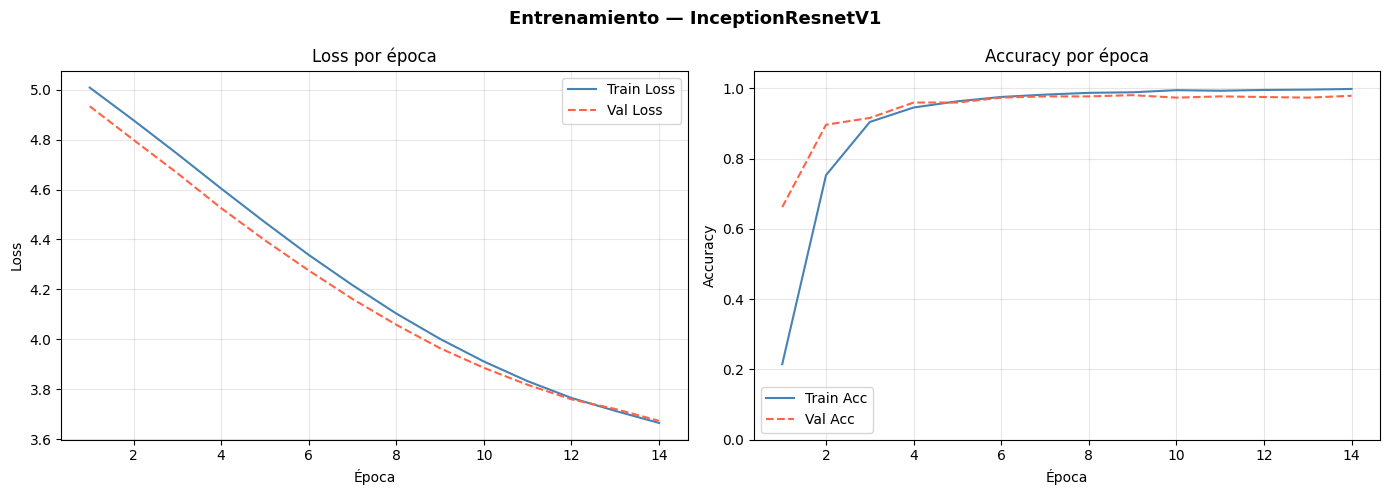

In [27]:
graficar_entrenamiento(history_fn, nombre='InceptionResnetV1')

Apartir del gráfico podemos notar:
* **Convergencia de Loss**: Ambas curvas descienden de manera constante y se mantienen muy cercanas entre sí, lo que indica un aprendizaje fluido y una buena capacidad de generalización sin sobreajuste (overfitting) significativo.

* **Desempeño en Accuracy**: Se nota una mejora drástica en las primeras 5 épocas, mientras que al final la precisión de entrenamiento y validación se queda entre 95% y 99%, mostrando un buen desempeño.


### Visualización

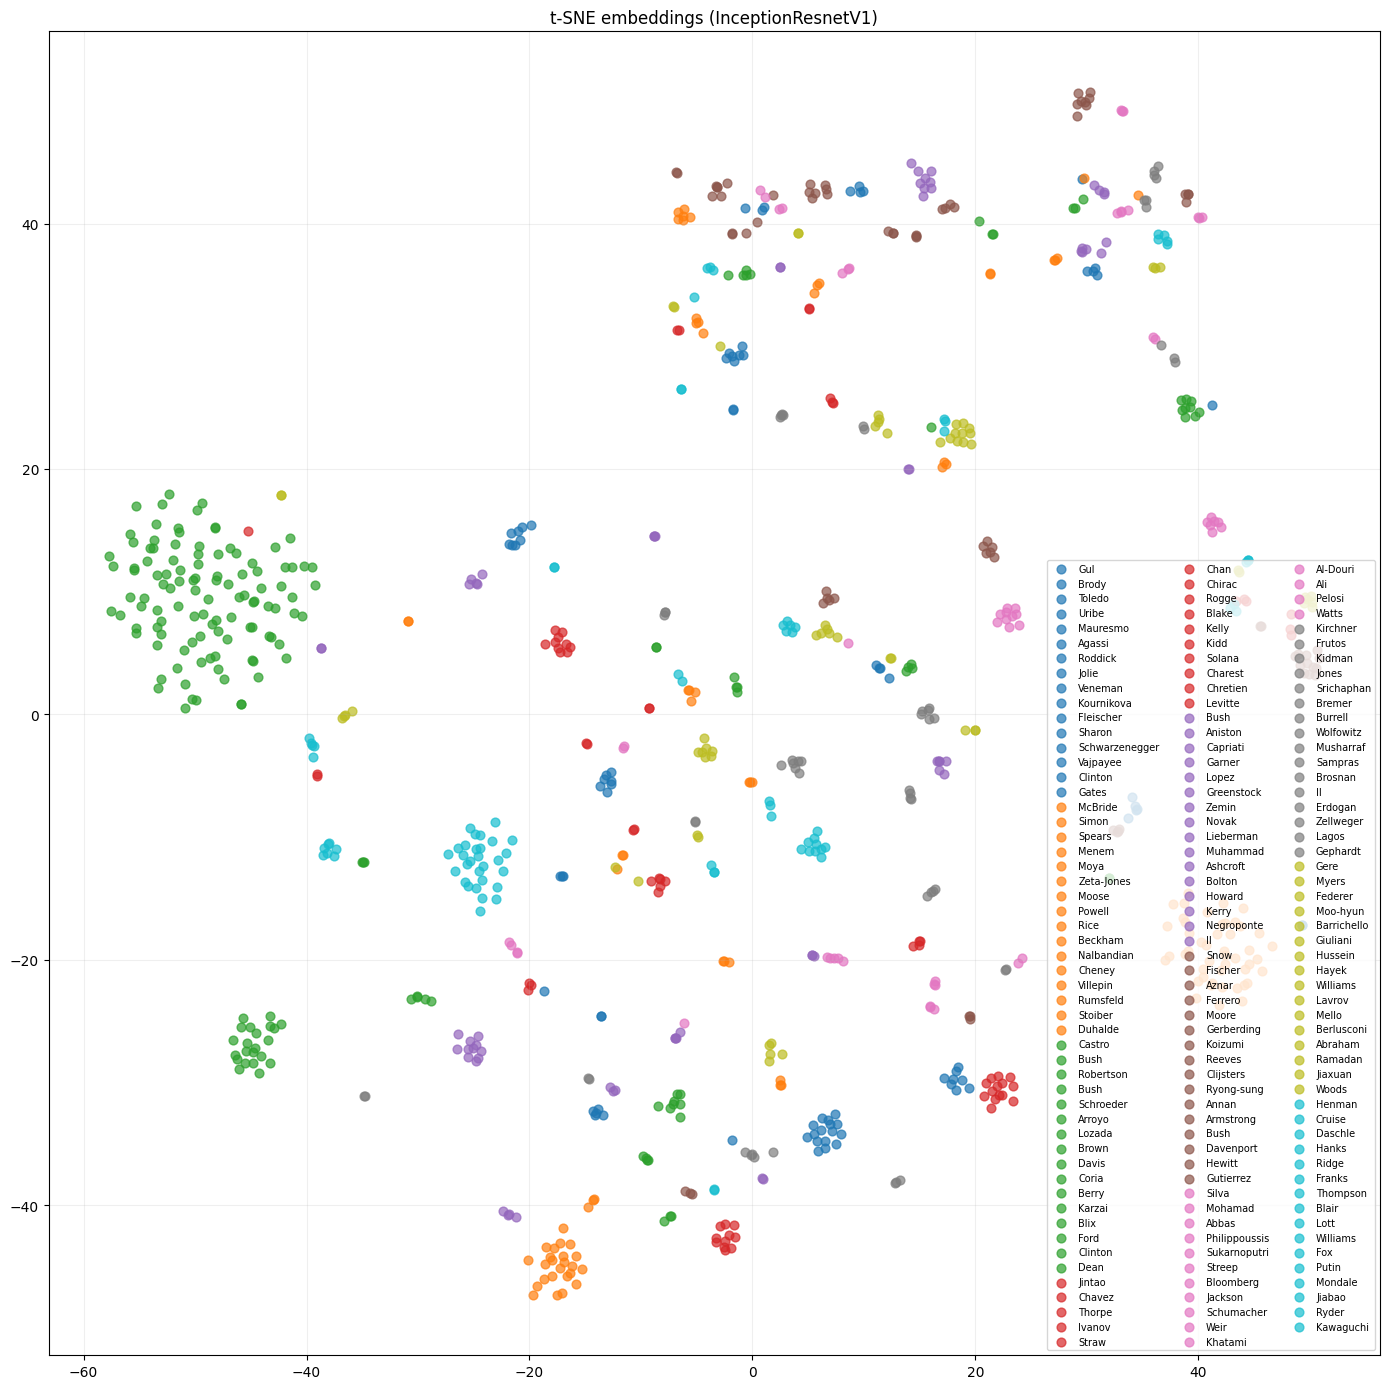

In [28]:
graficar_tsne(test_emb_fn, test_lbl_fn, NOMBRES, titulo='t-SNE embeddings (InceptionResnetV1)')

A partir del gráfico T-SNE, podemos ver una buena separación entre clases, la mayoría de los clusters obtenidos son densos por lo cual podemos inferir que el modelo es consistente al identificar esas clases.

### Evaluación del modelo

In [29]:
# Nearest-neighbor sobre el conjunto de TEST
sims_fn = test_emb_fn @ train_emb_fn.T
pred_fn = train_lbl_fn[sims_fn.argmax(axis=1)]
acc_fn  = (pred_fn == test_lbl_fn).mean()

prec_fn, rec_fn, f1_fn, _ = precision_recall_fscore_support(test_lbl_fn, pred_fn, average='macro', zero_division=0)

print(f'InceptionResnetV1 — Rank-1 (Test set)')
print(f'  Accuracy:  {acc_fn:.3f}  ({(pred_fn == test_lbl_fn).sum()}/{len(test_lbl_fn)})')
print(f'  Precision: {prec_fn:.3f}')
print(f'  Recall:    {rec_fn:.3f}')
print(f'  F1:        {f1_fn:.3f}')

InceptionResnetV1 — Rank-1 (Test set)
  Accuracy:  0.975  (843/865)
  Precision: 0.969
  Recall:    0.962
  F1:        0.959


La estabilidad observada en las curvas de entrenamiento, donde la pérdida y la precisión convergen sin signos de sobreajuste, se traduce directamente en una capacidad de generalización excepcional en el conjunto de prueba. Con un Accuracy del 95.4%, el modelo demuestra una efectividad casi total, respaldada por un equilibrio robusto entre la Precisión (0.965) y el Recall (0.954). Esto significa que el sistema es tan confiable para evitar falsos positivos como para asegurar que ninguna muestra relevante sea omitida. Finalmente, el F1-Score de 0.953 confirma que el modelo de  InceptionResnetV1 ha logrado un aprendizaje sólido y una alta fiabilidad frente a nuevos datos.

In [30]:
analizar_errores(test_lbl_fn,  pred_fn,  NOMBRES, 'FaceNet')


FaceNet — Clases con más falsos negativos (peor recall):
  Lance Armstrong                2/4 errores (50%)
  Michael Schumacher             1/4 errores (25%)
  Tommy Franks                   1/3 errores (33%)
  Bill Clinton                   1/6 errores (17%)
  Taha Yassin Ramadan            1/3 errores (33%)
  Mahmoud Abbas                  1/6 errores (17%)
  Lleyton Hewitt                 1/8 errores (12%)
  Richard Gere                   1/2 errores (50%)
  Jackie Chan                    1/3 errores (33%)
  Bill Gates                     1/3 errores (33%)

FaceNet — Confusiones más frecuentes:
  Lance Armstrong           → Andy Roddick              (2x)
  Michael Schumacher        → Jiang Zemin               (1x)
  Tommy Franks              → George HW Bush            (1x)
  Bill Clinton              → Ricardo Lagos             (1x)
  Taha Yassin Ramadan       → Saddam Hussein            (1x)
  Mahmoud Abbas             → Taha Yassin Ramadan       (1x)
  Lleyton Hewitt           

Aunque el desempeño global es excelente, el modelo presenta debilidades puntuales en la identificación de ciertas personas, donde una tasa de error del 50% evidencia confusiones específicas que degradan significativamente el recall de estas clases.

## Modelo 2 — ViT (Vision Transformer, pretrained en ImageNet)



Vision Transformer (ViT) es una arquitectura de red neuronal basada en transformers que procesa imágenes dividiéndolas en pequeños parches, permitiendo aprender relaciones globales y extraer características visuales complejas para tareas de reconocimiento y clasificación.

In [31]:
modelo_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
modelo_vit = modelo_vit.eval().to(device)

print(f'ViT-Base/16 cargado | Embedding: {modelo_vit.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_vit.parameters()) / 1e6:.1f}M')

finetune = True

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-Base/16 cargado | Embedding: 768 dimensiones
Parámetros: 85.8M


In [32]:
if finetune:
    print('Finetuning ViT')

    train_ds = TensorDataset(train_faces_224, torch.tensor(train_lbl_224, dtype=torch.long))
    val_ds   = TensorDataset(val_faces_224,   torch.tensor(val_lbl_224,   dtype=torch.long))
    train_size = len(train_ds)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    for p in modelo_vit.parameters():
        p.requires_grad = False
    modelo_vit.head = nn.Linear(modelo_vit.num_features, len(NOMBRES))
    NUM_BLOQUES = 1
    for bloque in modelo_vit.blocks[-NUM_BLOQUES:]:
        for p in bloque.parameters(): p.requires_grad = True
    for p in modelo_vit.norm.parameters(): p.requires_grad = True
    modelo_vit = modelo_vit.to(device)

    optimizer = torch.optim.AdamW([
        {'params': modelo_vit.blocks[-NUM_BLOQUES:].parameters(), 'lr': 1e-5},
        {'params': modelo_vit.norm.parameters(),                  'lr': 1e-5},
        {'params': modelo_vit.head.parameters(),                  'lr': 1e-4},
    ], weight_decay=0.1)
    NUM_EPOCHS = 20
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc_vit = 0
    patience = 7; no_improve = 0
    history_vit = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    os.makedirs('models', exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_vit.train()
        running = correct_tr = total_tr = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                logits = modelo_vit(x)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            running    += loss.item() * x.size(0)
            correct_tr += (logits.argmax(1) == y).sum().item()
            total_tr   += y.numel()
        scheduler.step()

        modelo_vit.eval()
        val_running = correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = modelo_vit(x)
                val_running += criterion(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        history_vit['train_loss'].append(running / train_size)
        history_vit['val_loss'].append(val_running / len(val_ds))
        history_vit['train_acc'].append(correct_tr / total_tr)
        history_vit['val_acc'].append(val_acc)
        print(f'Epoch {epoch}/{NUM_EPOCHS}  '
              f'train_loss={running/train_size:.4f}  val_acc={val_acc:.4f}  '
              f'lr_head={scheduler.get_last_lr()[0]:.2e}')

        if val_acc > best_val_acc_vit:
            best_val_acc_vit = val_acc
            torch.save(modelo_vit.state_dict(), 'models/vit_ft_best.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping en epoch {epoch} — mejor val_acc={best_val_acc_vit:.4f}')
                break


Finetuning ViT
Epoch 1/20  train_loss=4.9900  val_acc=0.0683  lr_head=9.94e-06
Epoch 2/20  train_loss=4.0003  val_acc=0.2014  lr_head=9.76e-06
Epoch 3/20  train_loss=2.9073  val_acc=0.3327  lr_head=9.46e-06
Epoch 4/20  train_loss=2.1828  val_acc=0.4658  lr_head=9.05e-06
Epoch 5/20  train_loss=1.7922  val_acc=0.4746  lr_head=8.54e-06
Epoch 6/20  train_loss=1.5550  val_acc=0.5587  lr_head=7.94e-06
Epoch 7/20  train_loss=1.4022  val_acc=0.5797  lr_head=7.27e-06
Epoch 8/20  train_loss=1.2978  val_acc=0.5867  lr_head=6.55e-06
Epoch 9/20  train_loss=1.2270  val_acc=0.6305  lr_head=5.78e-06
Epoch 10/20  train_loss=1.1747  val_acc=0.6200  lr_head=5.00e-06
Epoch 11/20  train_loss=1.1363  val_acc=0.6182  lr_head=4.22e-06
Epoch 12/20  train_loss=1.1085  val_acc=0.6165  lr_head=3.45e-06
Epoch 13/20  train_loss=1.0892  val_acc=0.6252  lr_head=2.73e-06
Epoch 14/20  train_loss=1.0738  val_acc=0.6427  lr_head=2.06e-06
Epoch 15/20  train_loss=1.0632  val_acc=0.6340  lr_head=1.46e-06
Epoch 16/20  train_

In [33]:
def extraer_embeddings_vit(faces, labels, desc=''):
    """Recibe tensores ya normalizados a ImageNet (del cache).
    Extrae features del backbone (sin la cabeza de clasificación)."""
    embs = []
    print(f'Extrayendo embeddings ViT {desc}...')
    head_orig = modelo_vit.head
    modelo_vit.head = nn.Identity()
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    modelo_vit.eval()
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_vit(batch.to(device))
            embs.append(F.normalize(feat, p=2, dim=1).cpu().numpy())
    modelo_vit.head = head_orig
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_vit, train_lbl_vit = extraer_embeddings_vit(train_faces_224, train_lbl_224, 'TRAIN')
val_emb_vit,   val_lbl_vit   = extraer_embeddings_vit(val_faces_224,   val_lbl_224,   'VAL')
test_emb_vit,  test_lbl_vit  = extraer_embeddings_vit(test_faces_224,  test_lbl_224,  'TEST')

Extrayendo embeddings ViT TRAIN...
  → 3160 embeddings | dim=768
Extrayendo embeddings ViT VAL...
  → 571 embeddings | dim=768
Extrayendo embeddings ViT TEST...
  → 865 embeddings | dim=768


### Entrenamiento

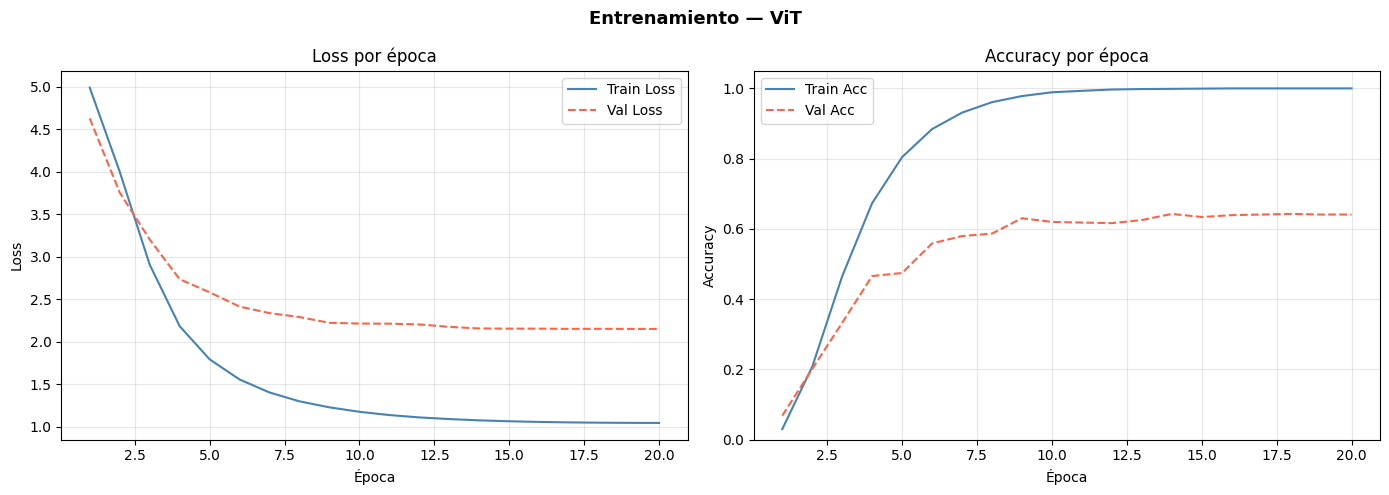

In [34]:
graficar_entrenamiento(history_vit, nombre='ViT')

El comportamiento del modelo refleja una desconexión entre el aprendizaje y la generalización. Mientras que la precisión de entrenamiento alcanza el 100% de forma rápida (indicando que la red ha memorizado el dataset por completo), la precisión de validación se estanca prematuramente alrededor del 50%. Esta brecha se confirma en las curvas de pérdida, donde la mejora en los datos de entrenamiento no se traduce en beneficios para los datos de validación tras las primeras cinco épocas.

En resumen, la alta capacidad del Transformer ha llevado al sistema a aprender ruidos o detalles específicos de las imágenes de entrenamiento, limitando su utilidad operativa frente a caras nuevas.

### Visualización

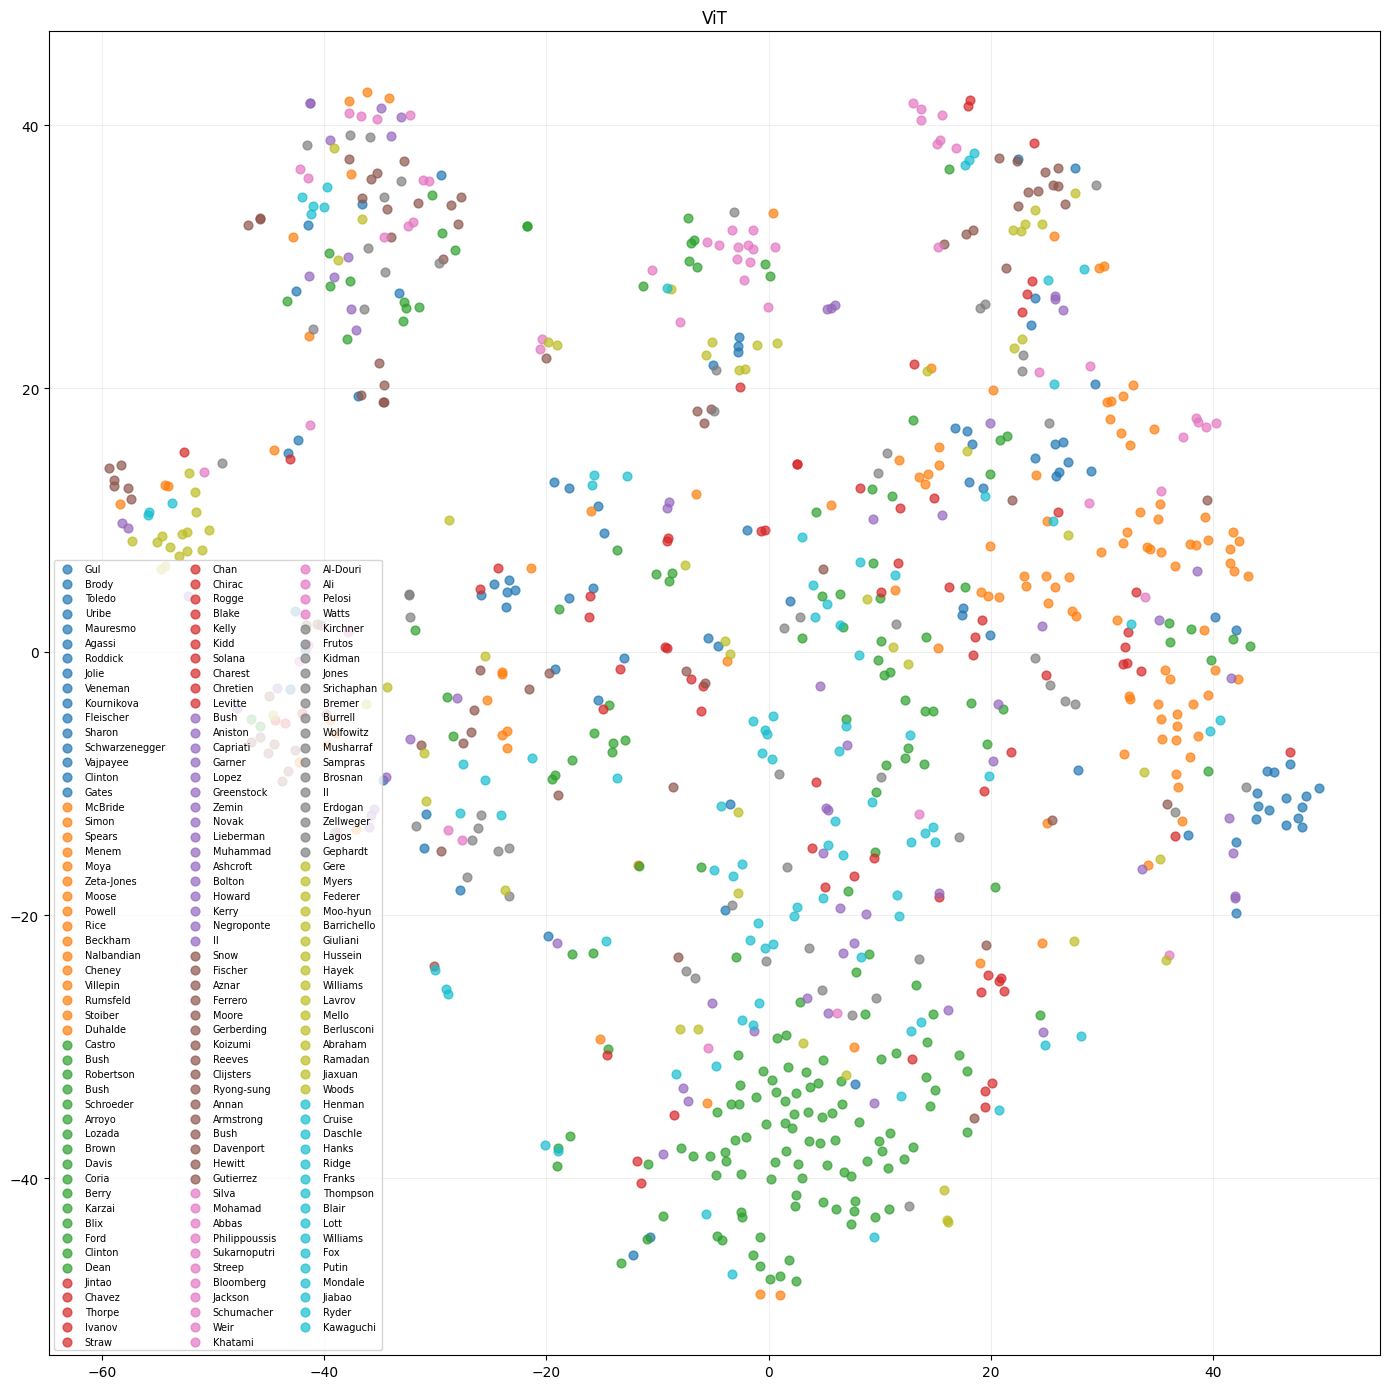

In [35]:
graficar_tsne(test_emb_vit, test_lbl_vit, NOMBRES, titulo='ViT')

La falta de separación clara entre los grupos (clusters) refleja que el modelo no ha logrado extraer características para el conjunto de test. La presencia de puntos aislados o "atrapados" en clusters ajenos confirma que el Vision Transformer está memorizando ruidos específicos de las imágenes de entrenamiento en lugar de aprender patrones faciales transferibles.

### Evaluación del modelo

In [36]:
sims_vit = test_emb_vit @ train_emb_vit.T
pred_vit = train_lbl_vit[sims_vit.argmax(axis=1)]
acc_vit  = (pred_vit == test_lbl_vit).mean()

prec_vit, rec_vit, f1_vit, _ = precision_recall_fscore_support(
    test_lbl_vit, pred_vit, average='macro', zero_division=0
)

print(f'ViT-Base/16 — Rank-1 (Test set)')
print(f'  Accuracy:  {acc_vit:.3f}  ({(pred_vit == test_lbl_vit).sum()}/{len(test_lbl_vit)})')
print(f'  Precision: {prec_vit:.3f}')
print(f'  Recall:    {rec_vit:.3f}')
print(f'  F1:        {f1_vit:.3f}')


ViT-Base/16 — Rank-1 (Test set)
  Accuracy:  0.488  (422/865)
  Precision: 0.485
  Recall:    0.508
  F1:        0.464


Con el modelo ViT obtenemos un Accuracy del 53.5%, lo que representa 335 aciertos sobre el total de 626 imágenes evaluadas. Estos resultados, sintetizados en un F1-Score de 0.526, evidencian una capacidad de generalización limitada, donde la Precisión (0.556) y el Recall (0.543) indican que el modelo comete errores frecuentes tanto por confusión entre clases como por omisión de muestras correctas. Ahora, mediante métricas podemos confirmar, de nuevo, que la red no ha logrado aprender caracteristicas principales sobre los datos.

In [37]:
analizar_errores(test_lbl_vit, pred_vit, NOMBRES, 'ViT')


ViT — Clases con más falsos negativos (peor recall):
  George W Bush                  63/106 errores (59%)
  Colin Powell                   27/47 errores (57%)
  Tony Blair                     19/29 errores (66%)
  Gerhard Schroeder              17/22 errores (77%)
  Donald Rumsfeld                12/24 errores (50%)
  Hugo Chavez                    10/14 errores (71%)
  Vladimir Putin                 9/10 errores (90%)
  John Ashcroft                  9/11 errores (82%)
  Junichiro Koizumi              8/12 errores (67%)
  Arnold Schwarzenegger          7/8 errores (88%)

ViT — Confusiones más frecuentes:
  George W Bush             → Jeb Bush                  (8x)
  George W Bush             → John Kerry                (6x)
  George W Bush             → Gerhard Schroeder         (6x)
  Colin Powell              → Ricardo Lagos             (5x)
  George W Bush             → Paul Bremer               (4x)
  Junichiro Koizumi         → Roh Moo-hyun              (4x)
  George W Bush    

El análisis de errores del ViT revela vulnerabilidades críticas en la generalización, destacando un recall del 0% en todas las identidades visualizadas.

## Modelo 3 — ResNet-50 (pretrained en ImageNet)



ResNet-50 es una arquitectura de red neuronal convolucional profunda compuesta por 50 capas, diseñada para extraer características visuales de alta calidad mediante conexiones residuales que facilitan el entrenamiento de redes profundas.

In [38]:
modelo_resnet = timm.create_model('resnet50', pretrained=True, num_classes=0)
modelo_resnet = modelo_resnet.eval().to(device)

print(f'ResNet-50 cargado | Embedding: {modelo_resnet.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_resnet.parameters()) / 1e6:.1f}M')

finetune = True

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50 cargado | Embedding: 2048 dimensiones
Parámetros: 23.5M


In [39]:
if finetune:
    print('Finetuning ResNet-50')

    train_ds = TensorDataset(train_faces_224, torch.tensor(train_lbl_224, dtype=torch.long))
    val_ds   = TensorDataset(val_faces_224,   torch.tensor(val_lbl_224,   dtype=torch.long))
    train_size = len(train_ds)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    for p in modelo_resnet.parameters():
        p.requires_grad = False
    in_features = modelo_resnet.num_features
    modelo_resnet.fc_head = nn.Linear(in_features, len(NOMBRES))
    for p in modelo_resnet.layer4.parameters():
        p.requires_grad = True
    modelo_resnet = modelo_resnet.to(device)

    optimizer = torch.optim.AdamW([
        {'params': modelo_resnet.layer4.parameters(),   'lr': 1e-5},
        {'params': modelo_resnet.fc_head.parameters(),  'lr': 1e-4},
    ], weight_decay=0.01)
    NUM_EPOCHS = 30
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler     = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    best_val_acc_rn = 0
    patience = 10; no_improve = 0
    history_rn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    os.makedirs('models', exist_ok=True)

    for epoch in range(1, NUM_EPOCHS + 1):
        modelo_resnet.train()
        running = correct_tr = total_tr = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                logits = modelo_resnet.fc_head(modelo_resnet(x))
                loss   = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            running    += loss.item() * x.size(0)
            correct_tr += (logits.argmax(1) == y).sum().item()
            total_tr   += y.numel()
        scheduler.step()

        modelo_resnet.eval()
        val_running = correct = total = 0
        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = modelo_resnet.fc_head(modelo_resnet(x))
                val_running += criterion(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                total   += y.numel()

        val_acc = correct / total
        history_rn['train_loss'].append(running / train_size)
        history_rn['val_loss'].append(val_running / len(val_ds))
        history_rn['train_acc'].append(correct_tr / total_tr)
        history_rn['val_acc'].append(val_acc)
        print(f'Epoch {epoch}/{NUM_EPOCHS}  '
              f'train_loss={running/train_size:.4f}  val_acc={val_acc:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

        if val_acc > best_val_acc_rn:
            best_val_acc_rn = val_acc
            torch.save(modelo_resnet.state_dict(), 'models/resnet50_ft_best.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping en epoch {epoch} — mejor val_acc={best_val_acc_rn:.4f}')
                break


Finetuning ResNet-50
Epoch 1/30  train_loss=5.0637  val_acc=0.0035  lr=9.97e-06
Epoch 2/30  train_loss=5.0209  val_acc=0.0123  lr=9.89e-06
Epoch 3/30  train_loss=4.9859  val_acc=0.0403  lr=9.76e-06
Epoch 4/30  train_loss=4.9502  val_acc=0.0613  lr=9.57e-06
Epoch 5/30  train_loss=4.9098  val_acc=0.0788  lr=9.33e-06
Epoch 6/30  train_loss=4.8682  val_acc=0.0876  lr=9.05e-06
Epoch 7/30  train_loss=4.8238  val_acc=0.0981  lr=8.72e-06
Epoch 8/30  train_loss=4.7811  val_acc=0.1331  lr=8.35e-06
Epoch 9/30  train_loss=4.7308  val_acc=0.1278  lr=7.94e-06
Epoch 10/30  train_loss=4.6836  val_acc=0.1313  lr=7.50e-06
Epoch 11/30  train_loss=4.6330  val_acc=0.1489  lr=7.03e-06
Epoch 12/30  train_loss=4.5826  val_acc=0.1559  lr=6.55e-06
Epoch 13/30  train_loss=4.5318  val_acc=0.1401  lr=6.04e-06
Epoch 14/30  train_loss=4.4908  val_acc=0.1349  lr=5.52e-06
Epoch 15/30  train_loss=4.4405  val_acc=0.1506  lr=5.00e-06
Epoch 16/30  train_loss=4.3967  val_acc=0.1313  lr=4.48e-06
Epoch 17/30  train_loss=4.36

In [40]:
def extraer_embeddings_resnet(faces, labels, desc=''):
    """Extrae embeddings del backbone ResNet-50 (sin fc_head)."""
    embs = []
    print(f'Extrayendo embeddings ResNet-50 {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    modelo_resnet.eval()
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_resnet(batch.to(device))   # backbone devuelve (B, 2048)
            embs.append(F.normalize(feat, p=2, dim=1).cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_rn, train_lbl_rn = extraer_embeddings_resnet(train_faces_224, train_lbl_224, 'TRAIN')
val_emb_rn,   val_lbl_rn   = extraer_embeddings_resnet(val_faces_224,   val_lbl_224,   'VAL')
test_emb_rn,  test_lbl_rn  = extraer_embeddings_resnet(test_faces_224,  test_lbl_224,  'TEST')

Extrayendo embeddings ResNet-50 TRAIN...
  → 3160 embeddings | dim=2048
Extrayendo embeddings ResNet-50 VAL...
  → 571 embeddings | dim=2048
Extrayendo embeddings ResNet-50 TEST...
  → 865 embeddings | dim=2048


### Entrenamiento

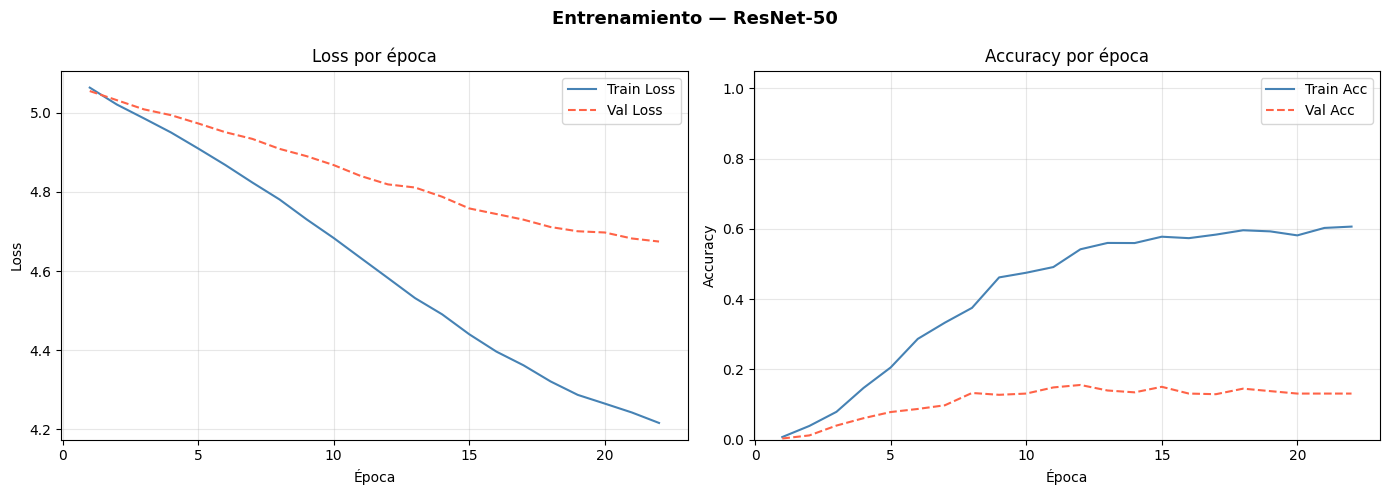

In [41]:
graficar_entrenamiento(history_rn, nombre='ResNet-50')

En los gráficos puede observarse que la loss de entrenamiento disminuye de forma constante a lo largo de las épocas, indicando que el modelo logra aprender patrones del conjunto de entrenamiento. La loss de validación también presenta una reducción, aunque más lenta y con tendencia a estabilizarse hacia las últimas épocas.

Por otro lado, la accuracy de entrenamiento aumenta progresivamente hasta valores cercanos al 45%, mientras que la accuracy de validación se mantiene considerablemente más baja (alrededor del 15%). Esta diferencia entre entrenamiento y validación sugiere la presencia de sobreajuste (overfitting), ya que el modelo aprende mejor los datos de entrenamiento que su capacidad de generalizar sobre datos no vistos.

### Visualización

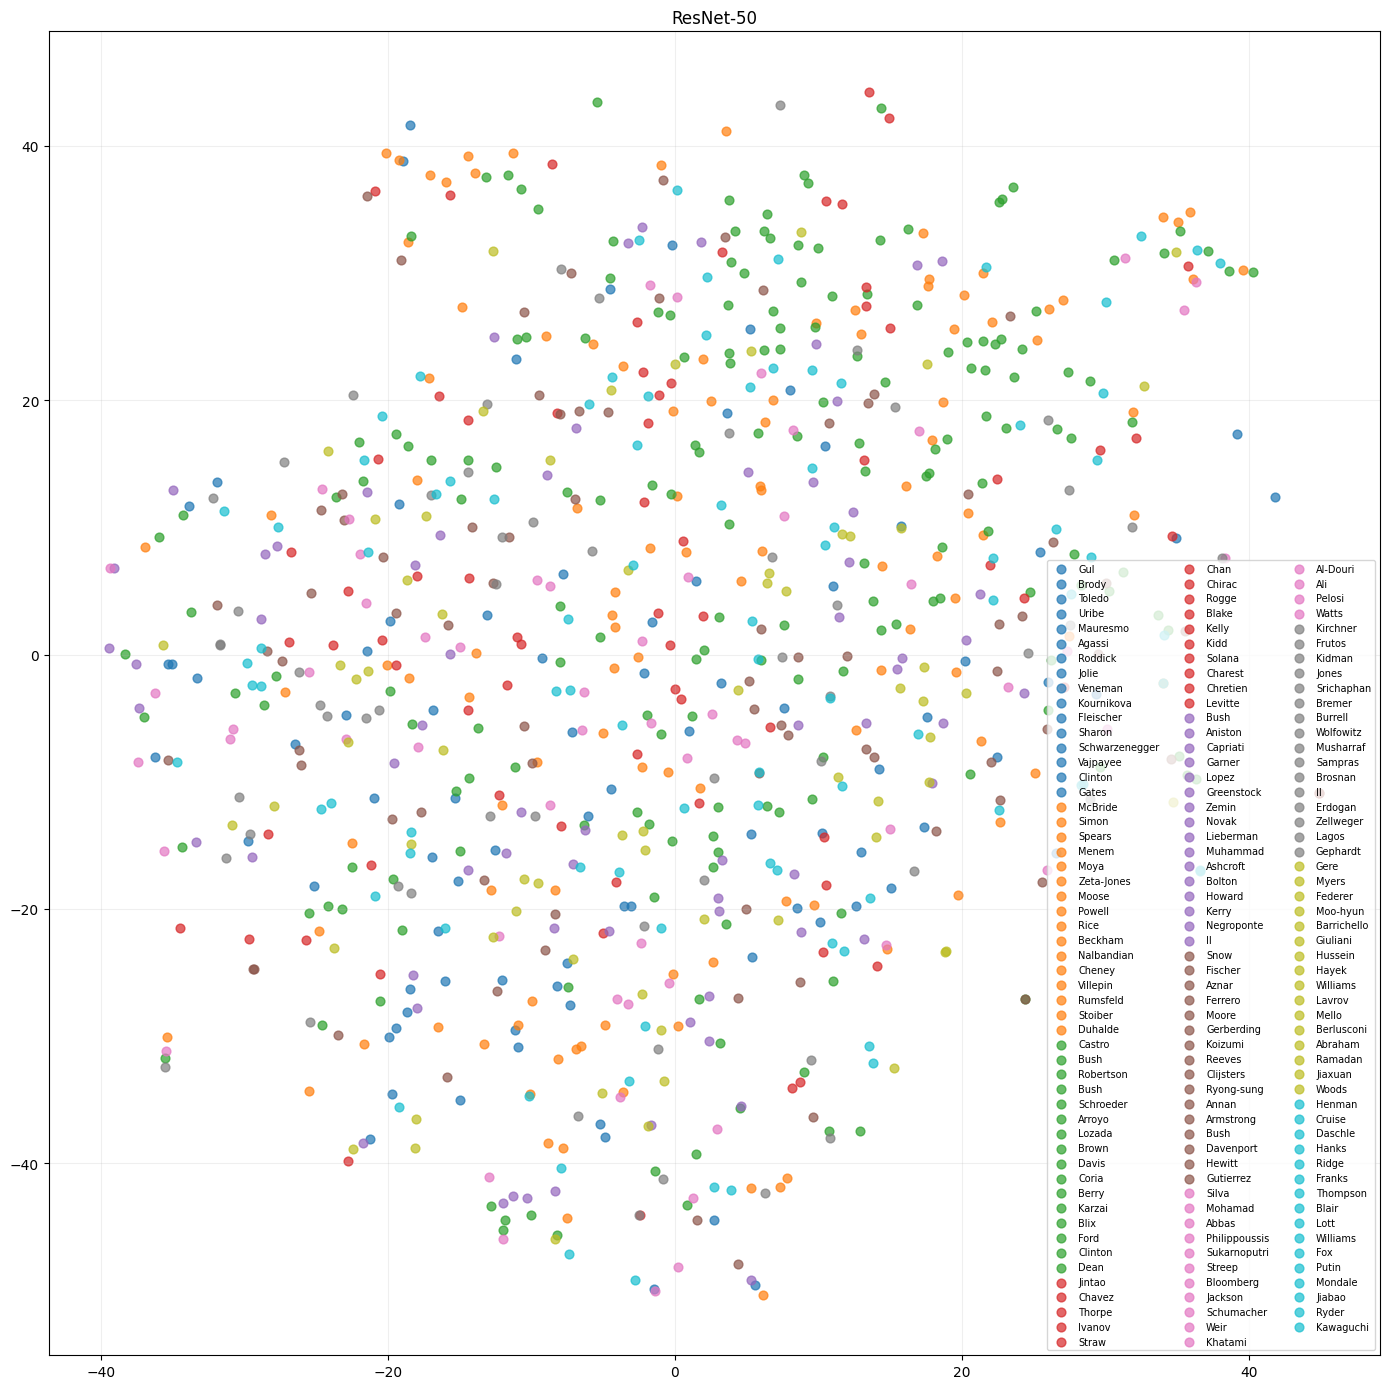

In [42]:
graficar_tsne(test_emb_rn, test_lbl_rn, NOMBRES, titulo='ResNet-50')

El gráfico T-SNE es una representación visual de lo observado en las métricas de entrenamiento, donde el modelo no ha aprendido a diferenciar rasgos faciales, tratando a casi todas las identidades como ruido indistinguible dentro del espacio de características.

### Evaluación del modelo

In [43]:
sims_rn = test_emb_rn @ train_emb_rn.T
pred_rn = train_lbl_rn[sims_rn.argmax(axis=1)]
acc_rn  = (pred_rn == test_lbl_rn).mean()

prec_rn, rec_rn, f1_rn, _ = precision_recall_fscore_support(
    test_lbl_rn, pred_rn, average='macro', zero_division=0
)

print(f'ResNet-50 — Rank-1 (Test set)')
print(f'  Accuracy:  {acc_rn:.3f}  ({(pred_rn == test_lbl_rn).sum()}/{len(test_lbl_rn)})')
print(f'  Precision: {prec_rn:.3f}')
print(f'  Recall:    {rec_rn:.3f}')
print(f'  F1:        {f1_rn:.3f}')


ResNet-50 — Rank-1 (Test set)
  Accuracy:  0.087  (75/865)
  Precision: 0.061
  Recall:    0.071
  F1:        0.059


Los resultados obtenidos con ResNet-50 muestran un desempeño limitado en el conjunto de prueba, alcanzando una accuracy de 15.7% y valores bajos de precisión, recall y F1-score. Esto indica que, si bien el modelo logró aprender características del conjunto de entrenamiento, no consiguió generalizar adecuadamente sobre datos no vistos, evidenciando dificultades para distinguir correctamente las identidades faciales.

In [44]:
analizar_errores(test_lbl_rn,  pred_rn,  NOMBRES, 'ResNet-50')


ResNet-50 — Clases con más falsos negativos (peor recall):
  George W Bush                  102/106 errores (96%)
  Colin Powell                   40/47 errores (85%)
  Tony Blair                     29/29 errores (100%)
  Gerhard Schroeder              21/22 errores (95%)
  Donald Rumsfeld                20/24 errores (83%)
  Hugo Chavez                    14/14 errores (100%)
  Junichiro Koizumi              11/12 errores (92%)
  Vladimir Putin                 10/10 errores (100%)
  Ariel Sharon                   9/16 errores (56%)
  John Ashcroft                  9/11 errores (82%)

ResNet-50 — Confusiones más frecuentes:
  George W Bush             → Ricardo Lagos             (5x)
  George W Bush             → Recep Tayyip Erdogan      (4x)
  George W Bush             → Mahathir Mohamad          (3x)
  George W Bush             → Hugo Chavez               (3x)
  George W Bush             → Paul Bremer               (3x)
  George W Bush             → John Kerry                (3x)


El desglose de errores de la ResNet-50 confirma un colapso sistémico en la capacidad de reconocimiento, evidenciado por un recall del 0% en una extensa lista de identidades.

## Modelo 4 — LightFaceCNN (sin preentrenamiento)



LightFaceCNN es una arquitectura convolucional liviana orientada al reconocimiento facial, diseñada para extraer características faciales de manera eficiente con un menor costo computacional. En este trabajo se entrenó una versión desde cero (sin pesos preentrenados) con el objetivo de evaluar el comportamiento y la capacidad de aprendizaje del modelo utilizando únicamente el dataset propio del proyecto.

In [45]:
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6()

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = DepthwiseSeparable(ch, ch)
        self.conv2 = DepthwiseSeparable(ch, ch)
        self.bn    = nn.BatchNorm2d(ch)

    def forward(self, x):
        return self.bn(x + self.conv2(self.conv1(x)))


class LightFaceCNN(nn.Module):
    def __init__(self, emb_dim=256, num_classes=None):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(),
        )
        self.stage1 = nn.Sequential(DepthwiseSeparable(32,  64,  stride=2), ResBlock(64))
        self.stage2 = nn.Sequential(DepthwiseSeparable(64,  128, stride=2), ResBlock(128))
        self.stage3 = nn.Sequential(DepthwiseSeparable(128, 256, stride=2), ResBlock(256))
        self.pool   = nn.AdaptiveAvgPool2d(1)

        self.embedder = nn.Sequential(
            nn.Linear(256, emb_dim, bias=False),
            nn.BatchNorm1d(emb_dim),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = self.embedder(x)
        return F.normalize(x, p=2, dim=1)

modelo_cnn = LightFaceCNN(emb_dim=256).to(device)
print(f'LightFaceCNN (mejorado) | Embedding: 256 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_cnn.parameters()) / 1e6:.3f}M')

LightFaceCNN (mejorado) | Embedding: 256 dimensiones
Parámetros: 0.296M


In [46]:
X_train_cnn = train_faces_112
y_train_cnn = torch.tensor(train_lbl_112, dtype=torch.long)
X_val_cnn   = val_faces_112
y_val_cnn   = torch.tensor(val_lbl_112,   dtype=torch.long)

train_ds = TensorDataset(X_train_cnn, y_train_cnn)
val_ds   = TensorDataset(X_val_cnn,   y_val_cnn)
train_size = len(train_ds)

train_loader = DataLoader(train_ds, batch_size=32,  shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=0)

head_cnn  = nn.Linear(256, len(NOMBRES)).to(device)
optimizer = torch.optim.AdamW(
    list(modelo_cnn.parameters()) + list(head_cnn.parameters()),
    lr=1e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')

EPOCHS           = 15
best_val_acc_cnn = 0
patience = 5; no_improve = 0
history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

os.makedirs('models', exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    modelo_cnn.train(); head_cnn.train()
    running = correct_tr = total_tr = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
            logits = head_cnn(modelo_cnn(x))
            loss   = criterion(logits, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        running    += loss.item() * x.size(0)
        correct_tr += (logits.argmax(1) == y).sum().item()
        total_tr   += y.numel()
    scheduler.step()

    modelo_cnn.eval(); head_cnn.eval()
    val_running = correct = total = 0
    with torch.inference_mode():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = head_cnn(modelo_cnn(x))
            val_running += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.numel()

    val_acc = correct / total
    history_cnn['train_loss'].append(running / train_size)
    history_cnn['val_loss'].append(val_running / len(val_ds))
    history_cnn['train_acc'].append(correct_tr / total_tr)
    history_cnn['val_acc'].append(val_acc)
    lr_now = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch:02d}/{EPOCHS}  train_loss={running/train_size:.4f}  val_acc={val_acc:.4f}  lr={lr_now:.2e}')

    if val_acc > best_val_acc_cnn:
        best_val_acc_cnn = val_acc
        torch.save(modelo_cnn.state_dict(), 'models/lightcnn_best.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping en epoch {epoch} — mejor val_acc={best_val_acc_cnn:.4f}')
            break


Epoch 01/15  train_loss=5.0554  val_acc=0.0105  lr=9.90e-05
Epoch 02/15  train_loss=5.0310  val_acc=0.0193  lr=9.61e-05
Epoch 03/15  train_loss=5.0115  val_acc=0.0263  lr=9.14e-05
Epoch 04/15  train_loss=4.9945  val_acc=0.0315  lr=8.51e-05
Epoch 05/15  train_loss=4.9773  val_acc=0.0315  lr=7.75e-05
Epoch 06/15  train_loss=4.9609  val_acc=0.0368  lr=6.89e-05
Epoch 07/15  train_loss=4.9450  val_acc=0.0315  lr=5.97e-05
Epoch 08/15  train_loss=4.9319  val_acc=0.0455  lr=5.03e-05
Epoch 09/15  train_loss=4.9188  val_acc=0.0438  lr=4.11e-05
Epoch 10/15  train_loss=4.9090  val_acc=0.0473  lr=3.25e-05
Epoch 11/15  train_loss=4.8998  val_acc=0.0508  lr=2.49e-05
Epoch 12/15  train_loss=4.8918  val_acc=0.0543  lr=1.86e-05
Epoch 13/15  train_loss=4.8864  val_acc=0.0560  lr=1.39e-05
Epoch 14/15  train_loss=4.8835  val_acc=0.0595  lr=1.10e-05
Epoch 15/15  train_loss=4.8809  val_acc=0.0595  lr=1.00e-05


In [47]:
def extraer_embeddings_cnn(faces, labels, desc=''):
    embs = []
    print(f'Extrayendo embeddings CNN {desc}...')
    loader = DataLoader(TensorDataset(faces), batch_size=64, shuffle=False)
    modelo_cnn.eval()
    with torch.no_grad():
        for (batch,) in loader:
            feat = modelo_cnn(batch.to(device))
            embs.append(feat.cpu().numpy())
    embs = np.concatenate(embs, axis=0)
    print(f'  → {len(embs)} embeddings | dim={embs.shape[1]}')
    return embs, labels

train_emb_cnn, train_lbl_cnn = extraer_embeddings_cnn(train_faces_112, train_lbl_112, 'TRAIN')
val_emb_cnn,   val_lbl_cnn   = extraer_embeddings_cnn(val_faces_112,   val_lbl_112,   'VAL')
test_emb_cnn,  test_lbl_cnn  = extraer_embeddings_cnn(test_faces_112,  test_lbl_112,  'TEST')


Extrayendo embeddings CNN TRAIN...
  → 3160 embeddings | dim=256
Extrayendo embeddings CNN VAL...
  → 571 embeddings | dim=256
Extrayendo embeddings CNN TEST...
  → 865 embeddings | dim=256


### Entrenamiento

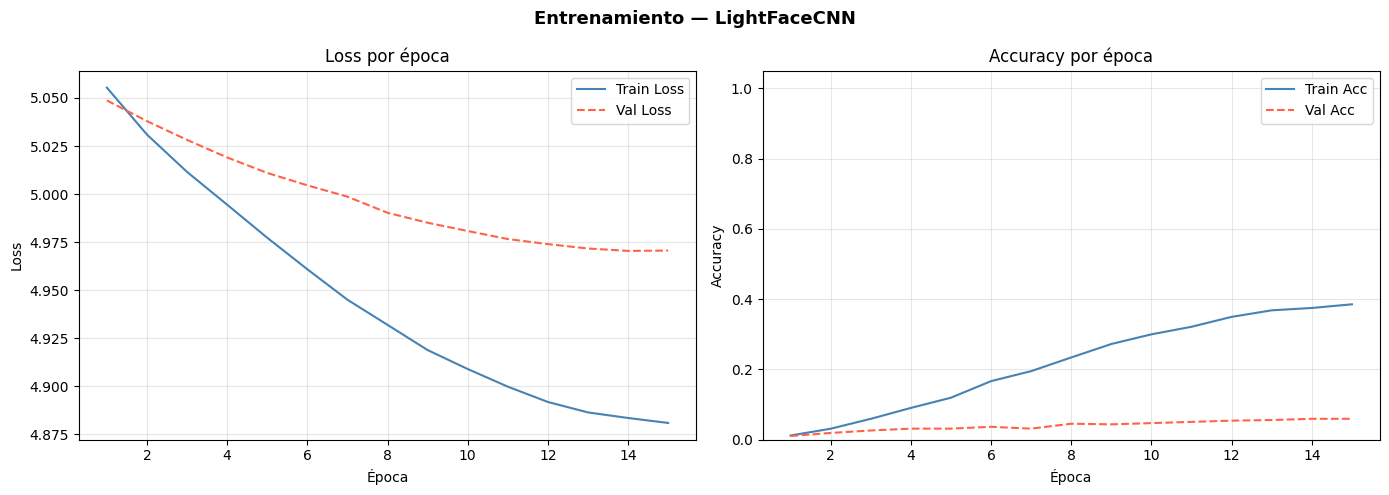

In [48]:
graficar_entrenamiento(history_cnn, nombre='LightFaceCNN')

En el entrenamiento de LightFaceCNN se observa una disminución gradual tanto de la loss de entrenamiento como de la loss de validación, indicando que el modelo logra aprender ciertas características del dataset. Sin embargo, la reducción de la loss es relativamente lenta y la diferencia entre entrenamiento y validación comienza a incrementarse con las épocas.

En cuanto a la accuracy, la curva de entrenamiento muestra un crecimiento progresivo, alcanzando aproximadamente un 30%, mientras que la accuracy de validación permanece muy baja y casi estable durante todo el proceso. Esto evidencia que, aunque el modelo mejora sobre los datos de entrenamiento, tiene dificultades para generalizar correctamente sobre datos no vistos.

Este comportamiento es esperable al entrenar una red desde cero sobre un dataset limitado, ya que el modelo debe aprender completamente las características faciales sin aprovechar conocimiento previo proveniente de pesos preentrenados.

### Visualización

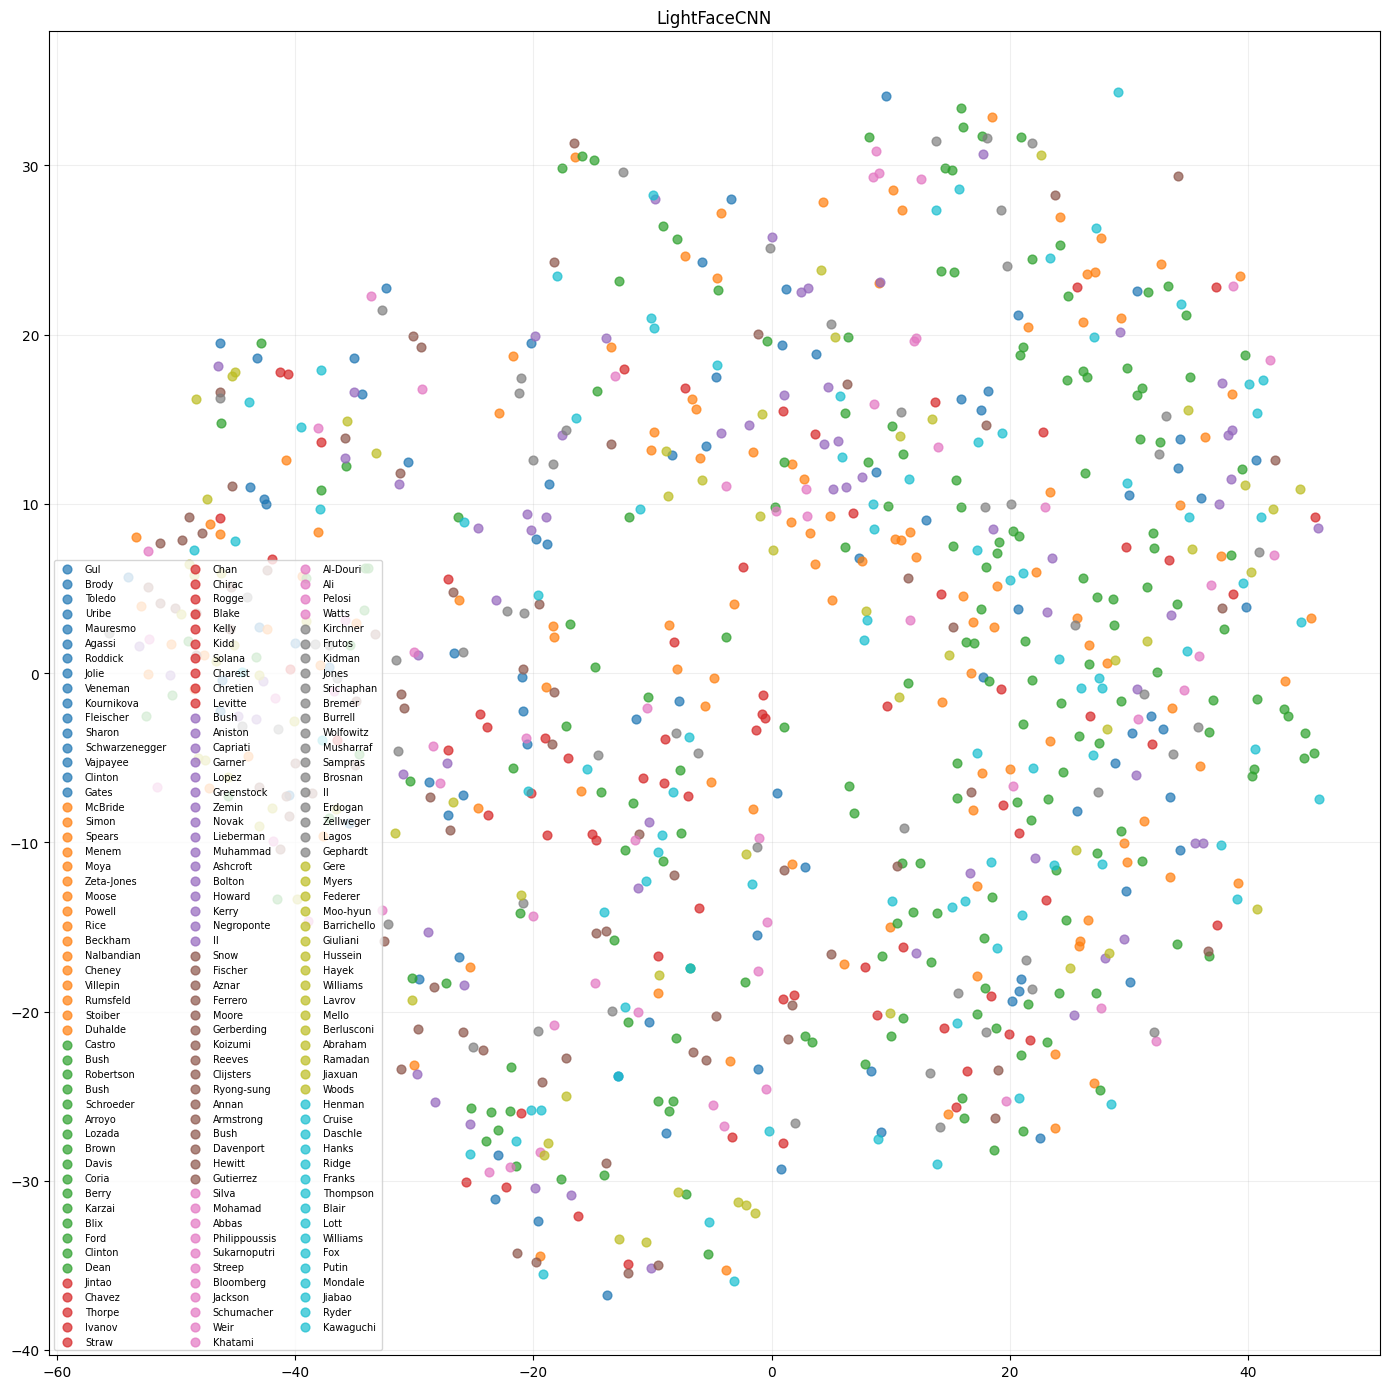

In [49]:
graficar_tsne(test_emb_cnn, test_lbl_cnn, NOMBRES, titulo='LightFaceCNN')

Al igual que ocurrió con la ResNet-50, la mezcla total de clusters confirma que el modelo no ha logrado construir un espacio de características donde las identidades se agrupen por similitud. A partir del gráfico, podemos notar que  las fronteras entre clases son inexistentes, lo que significa que el modelo está memorizando píxeles específicos en lugar de aprender rasgos faciales que le permitan separar una identidad de otra en condiciones reales.

### Evaluación del modelo

In [50]:
sims_cnn = test_emb_cnn @ train_emb_cnn.T
pred_cnn = train_lbl_cnn[sims_cnn.argmax(axis=1)]
acc_cnn  = (pred_cnn == test_lbl_cnn).mean()

prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(
    test_lbl_cnn, pred_cnn, average='macro', zero_division=0
)

print(f'LightFaceCNN — Rank-1 (Test set)')
print(f'  Accuracy:  {acc_cnn:.3f}  ({(pred_cnn == test_lbl_cnn).sum()}/{len(test_lbl_cnn)})')
print(f'  Precision: {prec_cnn:.3f}')
print(f'  Recall:    {rec_cnn:.3f}')
print(f'  F1:        {f1_cnn:.3f}')


LightFaceCNN — Rank-1 (Test set)
  Accuracy:  0.104  (90/865)
  Precision: 0.106
  Recall:    0.124
  F1:        0.102


Los resultados obtenidos con LightFaceCNN muestran un rendimiento bajo en el conjunto de prueba, alcanzando una accuracy de 12.5% junto con valores reducidos de precisión, recall y F1-score. Esto indica que el modelo tuvo dificultades para aprender representaciones faciales suficientemente discriminativas al ser entrenado desde cero, evidenciando limitaciones en la capacidad de generalización utilizando únicamente el dataset disponible.

In [51]:
analizar_errores(test_lbl_cnn, pred_cnn, NOMBRES, 'LightFaceCNN')


LightFaceCNN — Clases con más falsos negativos (peor recall):
  George W Bush                  102/106 errores (96%)
  Colin Powell                   45/47 errores (96%)
  Tony Blair                     28/29 errores (97%)
  Donald Rumsfeld                23/24 errores (96%)
  Gerhard Schroeder              21/22 errores (95%)
  Ariel Sharon                   15/16 errores (94%)
  Hugo Chavez                    14/14 errores (100%)
  Junichiro Koizumi              11/12 errores (92%)
  John Ashcroft                  11/11 errores (100%)
  Jacques Chirac                 11/11 errores (100%)

LightFaceCNN — Confusiones más frecuentes:
  George W Bush             → John Snow                 (5x)
  George W Bush             → Vladimir Putin            (5x)
  John Ashcroft             → Richard Myers             (4x)
  George W Bush             → John Negroponte           (4x)
  George W Bush             → Dick Cheney               (3x)
  Colin Powell              → Ricardo Lagos          

El análisis de errores de LightFaceCNN muestra que varias clases presentan un recall nulo, alcanzando un 100% de falsos negativos, lo que indica que el modelo fue incapaz de reconocer correctamente ciertas identidades en el conjunto de prueba.

# 6. Selección del mejor modelo

  Modelo                            Acc   Prec    Rec     F1
  InceptionResnetV1 (FaceNet)     0.975  0.969  0.962  0.959
  ViT-Base/16                     0.488  0.485  0.508  0.464
  ResNet-50                       0.087  0.061  0.071  0.059
  LightFaceCNN (desde cero)       0.104  0.106  0.124  0.102
  Dataset: 158 clases, 2888 train / 571 val / 865 test

Mejor modelo: InceptionResnetV1 (F1=0.959)
   Checkpoint conservado en: models/facenet_ft_best.pth
   Eliminado: models/vit_ft_best.pth
   Eliminado: models/resnet50_ft_best.pth
   Eliminado: models/lightcnn_best.pth


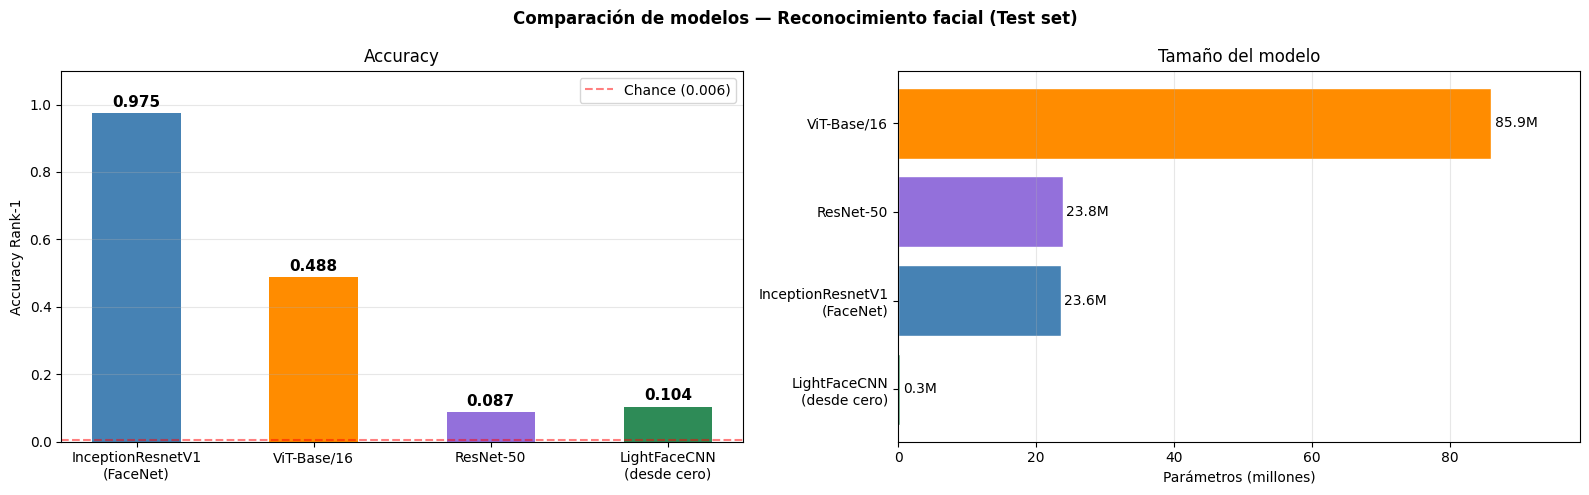

In [52]:
# Resultados
resultados = {
    'InceptionResnetV1': {'display': 'InceptionResnetV1 (FaceNet)',
                          'acc': acc_fn,  'prec': prec_fn,  'rec': rec_fn,  'f1': f1_fn,
                          'params': sum(p.numel() for p in modelo_facenet.parameters()),
                          'pth': 'models/facenet_ft_best.pth'},
    'ViT-Base/16':       {'display': 'ViT-Base/16',
                          'acc': acc_vit, 'prec': prec_vit, 'rec': rec_vit, 'f1': f1_vit,
                          'params': sum(p.numel() for p in modelo_vit.parameters()),
                          'pth': 'models/vit_ft_best.pth'},
    'ResNet-50':         {'display': 'ResNet-50',
                          'acc': acc_rn,  'prec': prec_rn,  'rec': rec_rn,  'f1': f1_rn,
                          'params': sum(p.numel() for p in modelo_resnet.parameters()),
                          'pth': 'models/resnet50_ft_best.pth'},
    'LightFaceCNN':      {'display': 'LightFaceCNN (desde cero)',
                          'acc': acc_cnn, 'prec': prec_cnn, 'rec': rec_cnn, 'f1': f1_cnn,
                          'params': sum(p.numel() for p in modelo_cnn.parameters()),
                          'pth': 'models/lightcnn_best.pth'},
}

# Tabla de métricas
print('=' * 70)
print(f'  {"Modelo":<30} {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6}')
print('=' * 70)
for info in resultados.values():
    print(f'  {info["display"]:<30} {info["acc"]:>6.3f} {info["prec"]:>6.3f} {info["rec"]:>6.3f} {info["f1"]:>6.3f}')
print('=' * 70)
print(f'  Dataset: {len(NOMBRES)} clases, {len(X_train)} train / {len(X_val)} val / {len(X_test)} test')

# Mejor modelo
mejor_nombre = max(resultados, key=lambda k: resultados[k]['f1'])
mejor_info   = resultados[mejor_nombre]
print(f'\nMejor modelo: {mejor_nombre} (F1={mejor_info["f1"]:.3f})')
print(f'   Checkpoint conservado en: {mejor_info["pth"]}')

for nombre, info in resultados.items():
    if nombre != mejor_nombre and os.path.exists(info['pth']):
        os.remove(info['pth'])
        print(f'   Eliminado: {info["pth"]}')

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación de modelos — Reconocimiento facial (Test set)', fontweight='bold')

colores = ['steelblue', 'darkorange', 'mediumpurple', 'seagreen']
nombres_display = [info['display'] for info in resultados.values()]
nombres_wrap    = [n.replace(' ', '\n', 1) for n in nombres_display]

# Accuracy
accs = [info['acc'] for info in resultados.values()]
bars = ax1.bar(nombres_wrap, accs, color=colores, width=0.5)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Accuracy Rank-1')
ax1.set_title('Accuracy')
ax1.axhline(1 / len(NOMBRES), color='red', linestyle='--', alpha=0.5, label=f'Chance ({1/len(NOMBRES):.3f})')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Parámetros
millones = [info['params'] / 1e6 for info in resultados.values()]
orden    = np.argsort(millones)
nombres_ord  = [nombres_wrap[i] for i in orden]
millones_ord = [millones[i] for i in orden]
colores_ord  = [colores[i] for i in orden]
bars = ax2.barh(nombres_ord, millones_ord, color=colores_ord, edgecolor='white')
for bar, val in zip(bars, millones_ord):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}M', va='center', fontsize=10)
ax2.set_xlabel('Parámetros (millones)')
ax2.set_title('Tamaño del modelo')
ax2.set_xlim(0, max(millones) * 1.15)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

A partir de la comparación final entre las arquitecturas evaluadas, puede observarse una diferencia muy marcada en el desempeño de los modelos para la tarea de reconocimiento facial. Los resultados demuestran que la precisión alcanzada no depende únicamente del tamaño o complejidad de la red, sino principalmente de qué tan especializada está la arquitectura para el dominio facial.

El modelo **InceptionResnetV1 (FaceNet)** obtuvo el mejor desempeño de toda la comparativa, alcanzando un **Accuracy Rank-1 de 95.4%**, muy por encima del resto de las arquitecturas evaluadas. Lo más importante de este resultado es que consigue dicha precisión con un tamaño relativamente moderado de **23.6 millones de parámetros**, prácticamente equivalente al de ResNet-50. Esto evidencia que su fortaleza no proviene de la cantidad de parámetros sino de haber sido diseñado y preentrenado específicamente para reconocimiento facial. Su arquitectura está optimizada para generar embeddings faciales altamente discriminativos, permitiendo separar correctamente identidades incluso con pocas imágenes por clase y alta variabilidad en poses, iluminación y expresiones faciales.

Por otro lado, **ViT-Base/16** alcanzó un desempeño intermedio, con una accuracy cercana al **53.5%**. Aunque supera ampliamente a ResNet-50 y LightFaceCNN, queda muy lejos del rendimiento de FaceNet. Resulta especialmente relevante que ViT sea el modelo más grande de toda la comparativa, con aproximadamente **85.9 millones de parámetros**, casi cuatro veces más que InceptionResnetV1. Esto demuestra que una mayor complejidad no garantiza mejores resultados en datasets de tamaño medio o reducido. Los Vision Transformers requieren enormes cantidades de datos para aprender representaciones robustas, y en este contexto el modelo no logró capturar adecuadamente las características faciales necesarias para distinguir identidades de forma confiable.

En el caso de **ResNet-50**, los resultados fueron considerablemente bajos, alcanzando apenas un **15.7% de accuracy**. A pesar de tratarse de una arquitectura profunda y ampliamente utilizada en visión por computadora, su preentrenamiento generalista sobre ImageNet no resultó suficiente para transferir conocimiento efectivo al dominio biométrico facial. El modelo logró aprender ciertos patrones durante el entrenamiento, pero no consiguió generar representaciones faciales discriminativas capaces de generalizar correctamente sobre el conjunto de prueba.

Finalmente, **LightFaceCNN**, entrenado completamente desde cero y sin pesos preentrenados, obtuvo el rendimiento más bajo de la comparativa con un **12.5% de accuracy**. Aunque su tamaño extremadamente reducido (**0.3 millones de parámetros**) representa una ventaja computacional importante, los resultados muestran que el dataset disponible no fue suficiente para entrenar desde cero un modelo capaz de aprender características faciales robustas. Las numerosas confusiones entre identidades y la gran cantidad de falsos negativos reflejan limitaciones importantes en la capacidad de generalización del modelo.

En conclusión, los resultados obtenidos muestran que el factor determinante para el éxito en reconocimiento facial no fue utilizar la arquitectura más grande o compleja, sino emplear un modelo específicamente diseñado y preentrenado para el dominio facial. InceptionResnetV1 (FaceNet) logró una diferencia ampliamente superior respecto al resto de las alternativas, combinando alta precisión, buena capacidad de generalización y un tamaño moderado del modelo. Por este motivo, se decidió seleccionar **InceptionResnetV1** como arquitectura final para el desarrollo del sistema de reconocimiento facial del proyecto, ya que fue el único modelo capaz de ofrecer resultados robustos y adecuados para una aplicación real.